📌  Objective

The objective of this project is to develop a forecasting model using Simple Moving Average (SMA), Weighted Moving Average (WMA), and Exponential Smoothing to predict future sales based on historical data.

Dataset : https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-writing-paper-sales.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:

df = pd.read_csv('monthly-writing-paper-sales.csv')

# Create proper monthly timeline
# Assuming the CSV contains a 'Sales' column and data starts from 2001-01

df['Month'] = pd.date_range(start='2001-01', periods=len(df), freq='M')

# Convert to readable format
df['Month'] = df['Month'].dt.strftime('%b-%Y')

df.head()

C:\Users\hiten\AppData\Local\Temp\ipykernel_78548\2966151079.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df['Month'] = pd.date_range(start='2001-01', periods=len(df), freq='M')


,Month,Sales
0,Jan-2001,1359.795
1,Feb-2001,1278.564
2,Mar-2001,1508.327
3,Apr-2001,1419.710
4,May-2001,1440.510


In [3]:
df["Time"] = range(1, len(df)+1)

df.head()

,Month,Sales,Time
0,Jan-2001,1359.795,1
1,Feb-2001,1278.564,2
2,Mar-2001,1508.327,3
3,Apr-2001,1419.710,4
4,May-2001,1440.510,5


In [4]:
n = 3        # try: 3, 5, 7
alpha = 0.5  # try: 0.2, 0.8

In [5]:
df['SMA'] = df['Sales'].rolling(window=n).mean()

df.head()

,Month,Sales,Time,SMA
0,Jan-2001,1359.795,1,NaN
1,Feb-2001,1278.564,2,NaN
2,Mar-2001,1508.327,3,1382.228667
3,Apr-2001,1419.710,4,1402.200333
4,May-2001,1440.510,5,1456.182333


In [6]:
weights = np.arange(1, n+1)

def calculate_wma(values):
    return np.dot(values, weights) / weights.sum()

df['WMA'] = df['Sales'].rolling(n).apply(calculate_wma, raw=True)

df.head()

,Month,Sales,Time,SMA,WMA
0,Jan-2001,1359.795,1,NaN,NaN
1,Feb-2001,1278.564,2,NaN,NaN
2,Mar-2001,1508.327,3,1382.228667,1406.984000
3,Apr-2001,1419.710,4,1402.200333,1425.724667
4,May-2001,1440.510,5,1456.182333,1444.879500


In [7]:
df['Exp_Smoothing'] = df['Sales'].ewm(alpha=alpha, adjust=False).mean()

df.head()

,Month,Sales,Time,SMA,WMA,Exp_Smoothing
0,Jan-2001,1359.795,1,NaN,NaN,1359.795000
1,Feb-2001,1278.564,2,NaN,NaN,1319.179500
2,Mar-2001,1508.327,3,1382.228667,1406.984000,1413.753250
3,Apr-2001,1419.710,4,1402.200333,1425.724667,1416.731625
4,May-2001,1440.510,5,1456.182333,1444.879500,1428.620813


In [8]:
print("Full Table:")
display(df)


Full Table:


,Month,Sales,Time,SMA,WMA,Exp_Smoothing
0,Jan-2001,1359.795,1,NaN,NaN,1359.795000
1,Feb-2001,1278.564,2,NaN,NaN,1319.179500
2,Mar-2001,1508.327,3,1382.228667,1406.984000,1413.753250
3,Apr-2001,1419.710,4,1402.200333,1425.724667,1416.731625
4,May-2001,1440.510,5,1456.182333,1444.879500,1428.620813
...,...,...,...,...,...,...
142,Nov-2012,1620.395,143,2031.551667,1931.498333,1847.928602
143,Dec-2012,1618.050,144,1830.663333,1724.747500,1732.989301
144,Jan-2013,1488.371,145,1575.605333,1553.601333,1610.680151
145,Feb-2013,1541.462,146,1549.294333,1536.529667,1576.071075


C:\Users\hiten\AppData\Local\Temp\ipykernel_78548\1942382532.py:24: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\hiten\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


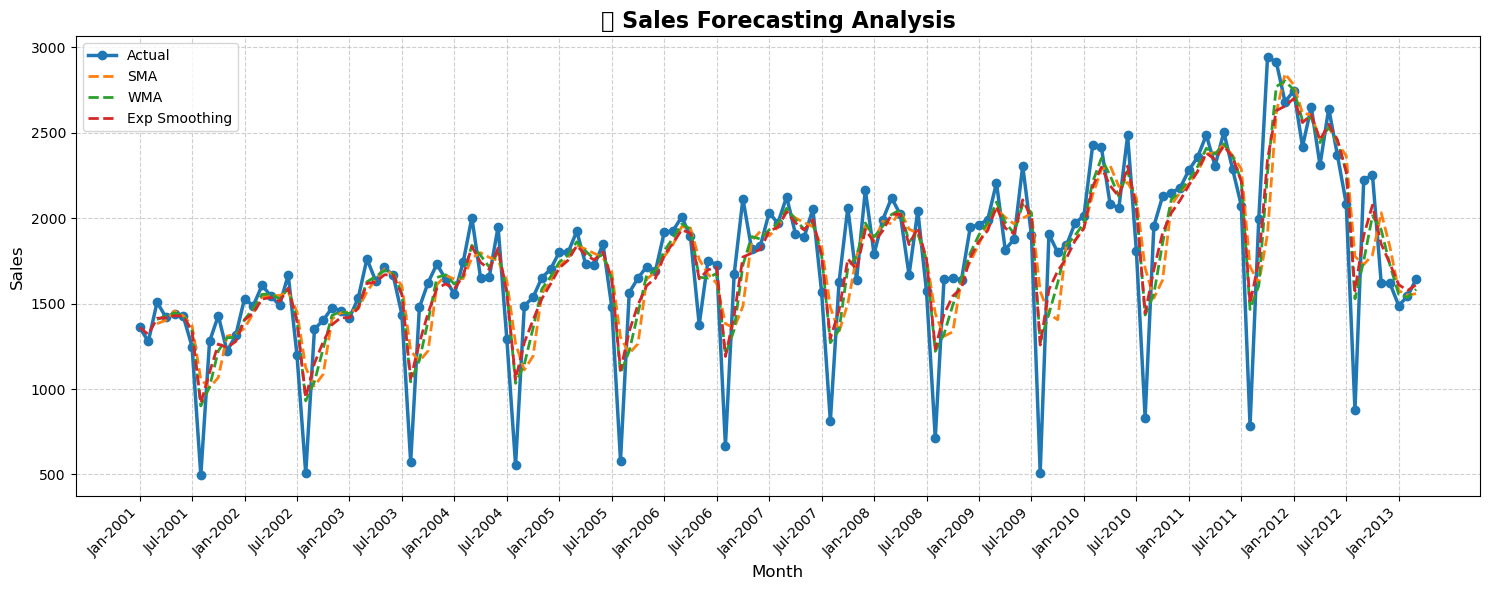

In [9]:
plt.figure(figsize=(15,6))

# Plot lines
plt.plot(df['Month'], df['Sales'], label='Actual', linewidth=2.5, marker='o')
plt.plot(df['Month'], df['SMA'], label='SMA', linestyle='--', linewidth=2)
plt.plot(df['Month'], df['WMA'], label='WMA', linestyle='--', linewidth=2)
plt.plot(df['Month'], df['Exp_Smoothing'], label='Exp Smoothing', linestyle='--', linewidth=2)

# Reduce x-axis labels
plt.xticks(df['Month'][::6], rotation=45, ha='right')

# Titles and labels
plt.title("📊 Sales Forecasting Analysis", fontsize=16, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Sales", fontsize=12)

# Grid styling
plt.grid(True, linestyle='--', alpha=0.6)

# Legend styling
plt.legend(loc='upper left', fontsize=10)

# Tight layout for spacing
plt.tight_layout()

plt.show()

# 📝 Methodology

-> Imported the monthly sales dataset into Python (Colab)

-> Preprocessed data by formatting the Month column and creating a Time index

-> Applied Simple Moving Average (SMA) using window size n

-> Applied Weighted Moving Average (WMA) with increasing weights for recent data

-> Applied Exponential Smoothing using smoothing factor α

-> Allowed dynamic adjustment of n and α for auto-updating forecasts

-> Generated forecast values for each method

-> Visualized actual vs forecasted values using graphs for comparison


# 📊 Insights

-> All methods capture the overall sales trend

-> SMA is smooth but lags behind actual values

-> WMA is more responsive than SMA

-> Exponential smoothing is the most adaptive and accurate

-> Higher n → smoother but slower response

-> Higher α → faster response to recent changes

-> Forecast helps in predicting future sales and decision-making
